# Single-Block Replacement Baseline

## Research question

How does a fixed reduced-width SwiGLU compare with dense linear and affine learned baselines and input-independent controls at zero-based SmolLM2 layer 11?

This notebook evaluates one deliberately chosen replacement, not an architecture search. Every condition uses the same held-out activation pairs and model-validation batches. Candidates are inserted one at a time, and model-level recovery is disabled.

## Compared conditions

| Condition | Role | Trainable replacement parameters |
| --- | --- | ---: |
| Original MLP | Uncompressed quality reference | Original block count |
| Zero | Complete-removal control | 0 |
| Mean | Calibration-output mean control | 0 |
| Dense linear | Learned bias-free $Ax$ baseline | $d_{\mathrm{model}}^2$ |
| Dense affine | Learned $Ax+b$ baseline | $d_{\mathrm{model}}^2+d_{\mathrm{model}}$ |
| Narrow SwiGLU | Learned practical replacement with width $r = 0.5d_{\mathrm{ff}}$ | $3d_{\mathrm{model}}r$ |

For the configured model, $d_{\mathrm{model}}=2048$, the original $d_{\mathrm{ff}}=8192$, and $r=4096$. The dense linear baseline has 4,194,304 parameters, while the narrow SwiGLU has 25,165,824 parameters, or 50% of the original 50,331,648-parameter MLP.

The width ratio is defined against the original MLP intermediate width, not the model input/output width. The fixed 50% ratio is a project decision for this baseline; results cannot establish that this width or operator family is optimal.

In [1]:
from dataclasses import asdict
from pathlib import Path
import json
import sys

def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from mlp_replacement.capture import collect_module_io
from mlp_replacement.config import DataConfig, ModelConfig, OperatorConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.language_model import evaluate_language_model
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.operators import (
    GatedMLPReplacement,
    MeanReplacement,
    ZeroReplacement,
    fit_operator,
    fit_ridge_linear,
)
from mlp_replacement.runlog import environment_record, json_value
from mlp_replacement.surgery import (
    count_parameters,
    count_state_elements,
    temporary_replacement,
)

sns.set_theme(style='whitegrid', context='notebook')

In [2]:
SEED = 21
TARGET_LAYER = 11

OUTPUT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / f'baselines-layer-{TARGET_LAYER}.json'
)
OUTPUT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / f'baselines-layer-{TARGET_LAYER}.json'
)

INTERMEDIATE_WIDTH_RATIO = 0.5
LINEAR_RIDGE = 1e-4

In [3]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)
data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=0,
    num_recovery_validation_batches=0,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)
training_config = OperatorConfig(
    kind='bottleneck_mlp',
    bottleneck_ratio=INTERMEDIATE_WIDTH_RATIO,
    activation='silu',
    bias=False,
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)
torch.manual_seed(SEED)

print({
    'target_layer': TARGET_LAYER,
    'intermediate_width_ratio': INTERMEDIATE_WIDTH_RATIO,
    'output': str(OUTPUT_PATH),
})

{'target_layer': 11, 'intermediate_width_ratio': 0.5, 'output': 'C:\\Users\\samue\\OneDrive - Univerzita Komenskeho v Bratislave\\Diplomová práca\\Diplomova Praca\\development\\data\\results\\notebook-block-study\\baselines-layer-11.json'}


## Shared data and block capture

Calibration pairs fit the learned replacement and define the mean control. A document-disjoint operator-validation split measures local approximation. WikiText-2 validation batches measure model loss and perplexity after temporary insertion.

In [4]:
model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device
loaders = build_data_loaders(tokenizer, data_config, include_recovery=False)
block = get_mlp_block(model, TARGET_LAYER)

capture_kwargs = {
    'device': device,
    'storage_device': 'cpu',
    'storage_dtype': torch.float32,
}
training_pairs = collect_module_io(
    model,
    block.path,
    loaders.calibration,
    data_config.num_calibration_batches,
    **capture_kwargs,
)
validation_pairs = collect_module_io(
    model,
    block.path,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    **capture_kwargs,
)

hidden_size = training_pairs.hidden_size
original_intermediate_width = int(block.module.up_proj.out_features)
replacement_width = max(
    1,
    round(INTERMEDIATE_WIDTH_RATIO * original_intermediate_width),
)
original_parameters = count_parameters(block.module)
original_state_elements = count_state_elements(block.module)

narrow_swiglu = GatedMLPReplacement(
    hidden_size,
    replacement_width,
    bias=False,
)
replacement_parameters = count_parameters(narrow_swiglu)
replacement_state_elements = count_state_elements(narrow_swiglu)

dense_linear = fit_ridge_linear(
    training_pairs,
    ridge=LINEAR_RIDGE,
    bias=False,
    device=device,
)
dense_linear_parameters = count_parameters(dense_linear)
dense_linear_state_elements = count_state_elements(dense_linear)

dense_affine = fit_ridge_linear(
    training_pairs,
    ridge=LINEAR_RIDGE,
    bias=True,
    device=device,
)
dense_affine_parameters = count_parameters(dense_affine)
dense_affine_state_elements = count_state_elements(dense_affine)

capture_df = pd.DataFrame([
    {
        'split': 'calibration',
        'tokens': training_pairs.inputs.shape[0],
        'input_dimension': training_pairs.inputs.shape[1],
        'target_dimension': training_pairs.targets.shape[1],
    },
    {
        'split': 'operator_validation',
        'tokens': validation_pairs.inputs.shape[0],
        'input_dimension': validation_pairs.inputs.shape[1],
        'target_dimension': validation_pairs.targets.shape[1],
    },
])
capture_df

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


,split,tokens,input_dimension,target_dimension
0,calibration,12288,2048,2048
1,operator_validation,6144,2048,2048


In [5]:
footprint_df = pd.DataFrame([
    {
        'operator': 'original_mlp',
        'intermediate_width': original_intermediate_width,
        'parameters': original_parameters,
        'state_elements': original_state_elements,
        'relative_block_parameters': 1.0,
        'parameter_reduction_percent': 0.0,
    },
    {
        'operator': 'dense_linear',
        'intermediate_width': None,
        'parameters': dense_linear_parameters,
        'state_elements': dense_linear_state_elements,
        'relative_block_parameters': (
            dense_linear_parameters / original_parameters
        ),
        'parameter_reduction_percent': 100 * (
            1 - dense_linear_parameters / original_parameters
        ),
    },
    {
        'operator': 'dense_affine',
        'intermediate_width': None,
        'parameters': dense_affine_parameters,
        'state_elements': dense_affine_state_elements,
        'relative_block_parameters': (
            dense_affine_parameters / original_parameters
        ),
        'parameter_reduction_percent': 100 * (
            1 - dense_affine_parameters / original_parameters
        ),
    },
    {
        'operator': 'narrow_swiglu',
        'intermediate_width': replacement_width,
        'parameters': replacement_parameters,
        'state_elements': replacement_state_elements,
        'relative_block_parameters': replacement_parameters / original_parameters,
        'parameter_reduction_percent': 100 * (
            1 - replacement_parameters / original_parameters
        ),
    },
])

expected_dense_linear_parameters = hidden_size * hidden_size
if dense_linear_parameters != expected_dense_linear_parameters:
    raise RuntimeError(
        'Unexpected dense-linear parameter count: '
        f'{dense_linear_parameters} != {expected_dense_linear_parameters}'
    )

expected_dense_affine_parameters = hidden_size * hidden_size + hidden_size
if dense_affine_parameters != expected_dense_affine_parameters:
    raise RuntimeError(
        'Unexpected dense-affine parameter count: '
        f'{dense_affine_parameters} != {expected_dense_affine_parameters}'
    )

expected_replacement_parameters = 3 * hidden_size * replacement_width
if replacement_parameters != expected_replacement_parameters:
    raise RuntimeError(
        'Unexpected narrow-SwiGLU parameter count: '
        f'{replacement_parameters} != {expected_replacement_parameters}'
    )
footprint_df

,operator,intermediate_width,parameters,state_elements,relative_block_parameters,parameter_reduction_percent
0,original_mlp,8192.0,50331648,50331648,1.000000,0.000000
1,dense_linear,NaN,4194304,4194304,0.083333,91.666667
2,dense_affine,NaN,4196352,4196352,0.083374,91.662598
3,narrow_swiglu,4096.0,25165824,25165824,0.500000,50.000000


## Fit and evaluate the six conditions

The zero and mean controls require no optimization. The dense linear and affine baselines are fitted by ridge regression, and the narrow SwiGLU is trained against the frozen teacher block output using activation MSE. Each replacement is then evaluated locally and inserted temporarily for the same language-model evaluation.

In [6]:
baseline_lm = evaluate_language_model(
    model,
    loaders.model_validation,
    device,
    data_config.num_model_validation_batches,
)
results = [{
    'name': 'original_mlp',
    'family': 'teacher',
    'parameters': original_parameters,
    'state_elements': original_state_elements,
    'relative_block_parameters': 1.0,
    'removed_parameters': 0,
    'local_mse': 0.0,
    'local_relative_mse': 0.0,
    'local_r2': 1.0,
    'local_cosine': 1.0,
    'local_norm_ratio': 1.0,
    'median_token_relative_error': 0.0,
    'p95_token_relative_error': 0.0,
    'loss': baseline_lm.loss,
    'perplexity': baseline_lm.perplexity,
    'delta_loss': 0.0,
    'delta_perplexity': 0.0,
    'recovery': False,
}]
training_histories = {}

def append_candidate(name, family, module, history=()):
    module = module.to(device)
    local = evaluate_operator(
        module,
        validation_pairs,
        device,
        training_config.batch_size,
    )
    with temporary_replacement(model, TARGET_LAYER, module) as record:
        integrated = evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )

    parameters = count_parameters(module)
    state_elements = count_state_elements(module)
    results.append({
        'name': name,
        'family': family,
        'parameters': parameters,
        'state_elements': state_elements,
        'relative_block_parameters': parameters / original_parameters,
        'removed_parameters': record.original_parameters - parameters,
        'local_mse': local.mse,
        'local_relative_mse': local.relative_mse,
        'local_r2': local.r2,
        'local_cosine': local.cosine_similarity,
        'local_norm_ratio': local.norm_ratio,
        'median_token_relative_error': local.median_token_relative_error,
        'p95_token_relative_error': local.p95_token_relative_error,
        'loss': integrated.loss,
        'perplexity': integrated.perplexity,
        'delta_loss': integrated.loss - baseline_lm.loss,
        'delta_perplexity': integrated.perplexity - baseline_lm.perplexity,
        'recovery': False,
    })
    training_histories[name] = [asdict(epoch) for epoch in history]

append_candidate(
    'zero',
    'constant_control',
    ZeroReplacement(),
)
append_candidate(
    'mean',
    'constant_control',
    MeanReplacement(training_pairs.targets.mean(dim=0)),
)

append_candidate(
    'dense_linear',
    'linear',
    dense_linear,
)

append_candidate(
    'dense_affine',
    'affine',
    dense_affine,
)

torch.manual_seed(SEED)
fit = fit_operator(
    narrow_swiglu,
    training_pairs,
    validation_pairs,
    training_config,
    device,
)
append_candidate(
    'narrow_swiglu',
    'gated_mlp',
    fit.module,
    fit.history,
)

results_df = pd.DataFrame(results)
if len(results_df) != 6:
    raise RuntimeError(f'Expected exactly six result rows, found {len(results_df)}')

## Learned-operator fit

The curves below diagnose optimization of the single learned replacement. They do not compare architectures.

,epoch,train_mse,validation_mse,learning_rate
0,1,1.597911,1.541330,0.001
1,2,1.558319,1.502728,0.001
2,3,1.511789,1.468639,0.001
3,4,1.458958,1.427313,0.001
4,5,1.399146,1.388471,0.001
5,6,1.333385,1.349276,0.001
6,7,1.271680,1.314504,0.001
7,8,1.210440,1.280508,0.001
8,9,1.152416,1.251465,0.001
9,10,1.100387,1.224799,0.001


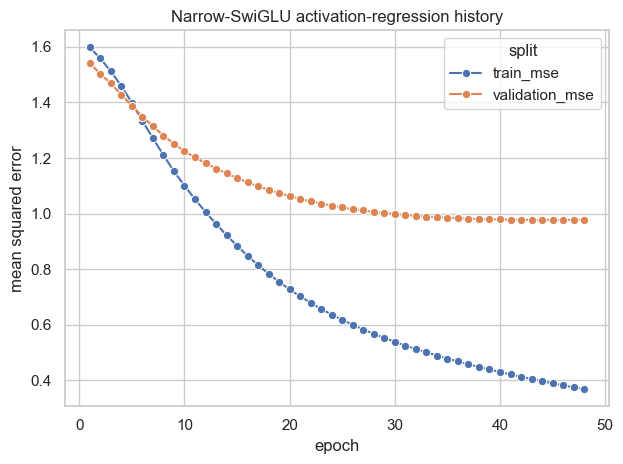

In [7]:
history_df = pd.DataFrame(training_histories['narrow_swiglu'])
history_long = history_df.melt(
    id_vars='epoch',
    value_vars=['train_mse', 'validation_mse'],
    var_name='split',
    value_name='mse',
)

ax = sns.lineplot(
    data=history_long,
    x='epoch',
    y='mse',
    hue='split',
    marker='o',
)
ax.set(
    title='Narrow-SwiGLU activation-regression history',
    ylabel='mean squared error',
)
plt.tight_layout()

history_df

## Footprint-quality report

The table retains the local approximation and integrated model metrics needed to interpret the replacement. The figure shows footprint and quality together without implying a searched Pareto frontier.

In [8]:
report_columns = [
    'name',
    'parameters',
    'state_elements',
    'relative_block_parameters',
    'local_relative_mse',
    'local_cosine',
    'loss',
    'perplexity',
    'delta_loss',
    'delta_perplexity',
]
results_df[report_columns]

,name,parameters,state_elements,relative_block_parameters,local_relative_mse,local_cosine,loss,perplexity,delta_loss,delta_perplexity
0,original_mlp,50331648,50331648,1.000000,0.000000,1.000000,2.670184,14.442631,0.000000,0.000000
1,zero,0,0,0.000000,1.000000,0.000000,2.738607,15.465423,0.068422,1.022792
2,mean,0,2048,0.000000,0.968756,0.169298,2.737667,15.450903,0.067483,1.008272
3,dense_linear,4194304,4194304,0.083333,0.700050,0.594335,2.726353,15.277072,0.056169,0.834441
4,dense_affine,4196352,4196352,0.083374,0.700126,0.605136,2.726373,15.277375,0.056189,0.834745
5,narrow_swiglu,25165824,25165824,0.500000,0.626773,0.616157,2.720437,15.186964,0.050253,0.744333


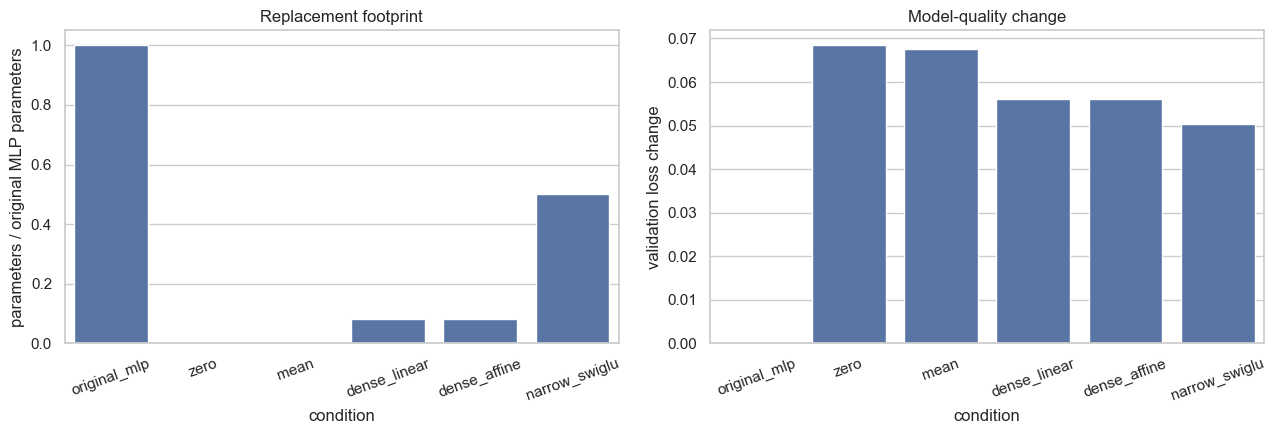

In [9]:
condition_order = [
    'original_mlp',
    'zero',
    'mean',
    'dense_linear',
    'dense_affine',
    'narrow_swiglu',
]
plot_df = results_df.set_index('name').loc[condition_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(
    data=plot_df,
    x='name',
    y='relative_block_parameters',
    order=condition_order,
    ax=axes[0],
)
sns.barplot(
    data=plot_df,
    x='name',
    y='delta_loss',
    order=condition_order,
    ax=axes[1],
)
axes[0].set(
    title='Replacement footprint',
    xlabel='condition',
    ylabel='parameters / original MLP parameters',
)
axes[1].set(
    title='Model-quality change',
    xlabel='condition',
    ylabel='validation loss change',
)
for axis in axes:
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()

In [10]:
artifact = {
    'schema_version': 2,
    'status': 'exploratory-unverified',
    'model': {
        'id': model_config.model_id,
        'resolved_revision': getattr(model.config, '_commit_hash', None),
        'target_layer': TARGET_LAYER,
        'mlp_path': block.path,
        'requested_config': asdict(model_config),
    },
    'data': {
        'sequence_length': data_config.sequence_length,
        'calibration_batches': data_config.num_calibration_batches,
        'operator_validation_batches': data_config.num_operator_validation_batches,
        'model_validation_batches': data_config.num_model_validation_batches,
        'seed': SEED,
        'requested_config': asdict(data_config),
    },
    'environment': environment_record(),
    'recovery': False,
    'replacement': {
        'name': 'narrow_swiglu',
        'family': 'gated_mlp',
        'definition': 'down(silu(gate(x)) * up(x))',
        'model_width': hidden_size,
        'original_intermediate_width': original_intermediate_width,
        'replacement_intermediate_width': replacement_width,
        'intermediate_width_ratio': (
            replacement_width / original_intermediate_width
        ),
        'bias': False,
        'parameters': replacement_parameters,
        'state_elements': replacement_state_elements,
        'relative_block_parameters': (
            replacement_parameters / original_parameters
        ),
    },
    'controls': ['original_mlp', 'zero', 'mean'],
    'dense_linear_baseline': {
        'definition': 'Ax',
        'bias': False,
        'ridge': LINEAR_RIDGE,
        'parameters': dense_linear_parameters,
        'state_elements': dense_linear_state_elements,
        'relative_block_parameters': (
            dense_linear_parameters / original_parameters
        ),
    },
    'dense_affine_baseline': {
        'definition': 'Ax+b',
        'bias': True,
        'ridge': LINEAR_RIDGE,
        'parameters': dense_affine_parameters,
        'state_elements': dense_affine_state_elements,
        'relative_block_parameters': (
            dense_affine_parameters / original_parameters
        ),
    },
    'operator_training': asdict(training_config),
    'baseline_language_model': asdict(baseline_lm),
    'results': results_df.to_dict(orient='records'),
    'training_histories': training_histories,
}
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(
    json.dumps(json_value(artifact), indent=2, allow_nan=False),
    encoding='utf-8',
)
print(f'Saved baseline summary to {OUTPUT_PATH}')

Saved baseline summary to C:\Users\samue\OneDrive - Univerzita Komenskeho v Bratislave\Diplomová práca\Diplomova Praca\development\data\results\notebook-block-study\baselines-layer-11.json


___

## Baseline Experiments

this part serves as an analysis to testing baseline behaviour across multiple settings. This part can stay here or later transfer to other analyses notebooks when baseline framework is encapsulated.

#### Compute Budget importance
ideas:
- testing different sizes of calibration batches (token count)

#### swiGLU analysis
ideas:
- testing different widths of hidden layer $d_{ff}$
- testing widths loss per layer depending on width ratio (baseline 0.25, 0.5, 0.75)

#### Multi-block analysis

ideas:
- test convergence on operator level in each block (e.g. barplot x=layer_idx, y=epoch_count)
- test convergence behaviour (difference) if calibration data size differs (more/less)

#### Plots analysis

ideas:
- variance of PPL/mse across blocks if calibration data increases (e.g. important layer)
    - answers: is it worth to increase calibration data based on BI?
    - visualization idea: violin/boxplot/swarmplot, x=layer, y=ppl/mse data points
    - hue idea: maybe operator class? or MLP width ratio? -> three bars next to each other 0.25, 0.5, 0.75 width